# Clustering Models - Comprehensive Demo & Tutorial

This notebook demonstrates various clustering algorithms using open-source datasets. You will learn:
- How to load and explore data
- Different clustering algorithms (K-means, DBSCAN, Hierarchical, GMM)
- How to evaluate and compare clustering results
- Data visualization in 2D and 3D spaces

---

## Step 1: Import Required Libraries

We'll use:
- **sklearn**: Machine learning algorithms and datasets
- **pandas**: Data manipulation
- **matplotlib & plotly**: Visualization (2D and 3D)
- **numpy**: Numerical operations

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px
from sklearn.datasets import load_iris, load_wine, load_digits, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Step 2: Load Open-Source Dataset

We'll use the **Iris Dataset** - a classic dataset with 150 samples and 4 features:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

**Note**: This dataset has 3 actual classes, but we'll treat them as unlabeled for clustering.

In [ ]:
# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y_true = iris.target  # Actual labels (for comparison only)
feature_names = iris.feature_names

# Create a DataFrame for better visualization
df = pd.DataFrame(X, columns=feature_names)
df['Actual_Class'] = y_true

print(f"Dataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"\nFeature names: {feature_names}")
print(f"\nFirst 5 samples:")
print(df.head())
print(f"\nDataset statistics:")
print(df.describe())

Dataset shape: (150, 4)
Number of features: 4
Number of samples: 150

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First 5 samples:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Actual_Class  
0             0  
1             0  
2             0  
3             0  
4             0  

Dataset statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std            

## Step 3: Data Preprocessing - Standardization

**Why standardize?**
- Clustering algorithms are distance-based (euclidean, manhattan)
- Features with larger ranges can dominate the distance calculation
- Standardization ensures all features contribute equally

**Method**: StandardScaler converts each feature to have mean=0 and std=1

In [ ]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify standardization
print("Before scaling:")
print(f"Mean: {X.mean(axis=0)}")
print(f"Std: {X.std(axis=0)}")
print(f"\nAfter scaling:")
print(f"Mean: {X_scaled.mean(axis=0)}")
print(f"Std: {X_scaled.std(axis=0)}")
print(f"\nMin values: {X_scaled.min(axis=0)}")
print(f"Max values: {X_scaled.max(axis=0)}")

Before scaling:
Mean: [5.84333333 3.05733333 3.758      1.19933333]
Std: [0.82530129 0.43441097 1.75940407 0.75969263]

After scaling:
Mean: [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Std: [1. 1. 1. 1.]

Min values: [-1.87002413 -2.43394714 -1.56757623 -1.44707648]
Max values: [2.4920192  3.09077525 1.78583195 1.71209594]


## Step 4: Dimensionality Reduction for Visualization

**Challenge**: We have 4 dimensions, but screens are 2D/3D.

**Solution**: Use PCA (Principal Component Analysis)
- Reduces 4D data to 2D or 3D
- Preserves maximum variance from original data
- Useful for visualization and sometimes improves clustering

In [ ]:
# Apply PCA for 2D visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"PCA 2D - Explained variance ratio: {pca_2d.explained_variance_ratio_}")
print(f"Total variance preserved: {pca_2d.explained_variance_ratio_.sum():.2%}")

# Apply PCA for 3D visualization
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"\nPCA 3D - Explained variance ratio: {pca_3d.explained_variance_ratio_}")
print(f"Total variance preserved: {pca_3d.explained_variance_ratio_.sum():.2%}")

PCA 2D - Explained variance ratio: [0.72962445 0.22850762]
Total variance preserved: 95.81%

PCA 3D - Explained variance ratio: [0.72962445 0.22850762 0.03668922]
Total variance preserved: 99.48%


## Step 5: Algorithm 1 - K-Means Clustering

**What is K-Means?**
- Partitions data into K clusters
- Each cluster is represented by its center (centroid)
- Algorithm:
  1. Randomly initialize K centroids
  2. Assign each point to nearest centroid
  3. Recalculate centroids as mean of cluster points
  4. Repeat steps 2-3 until convergence

**Hyperparameter**: n_clusters (we'll test different values)

K=2: Inertia=222.36, Silhouette Score=0.582
K=3: Inertia=139.82, Silhouette Score=0.460
K=4: Inertia=114.09, Silhouette Score=0.387
K=5: Inertia=90.93, Silhouette Score=0.346
K=6: Inertia=81.54, Silhouette Score=0.317
K=7: Inertia=72.63, Silhouette Score=0.320
K=8: Inertia=62.54, Silhouette Score=0.339
K=9: Inertia=55.12, Silhouette Score=0.342
K=10: Inertia=47.39, Silhouette Score=0.352


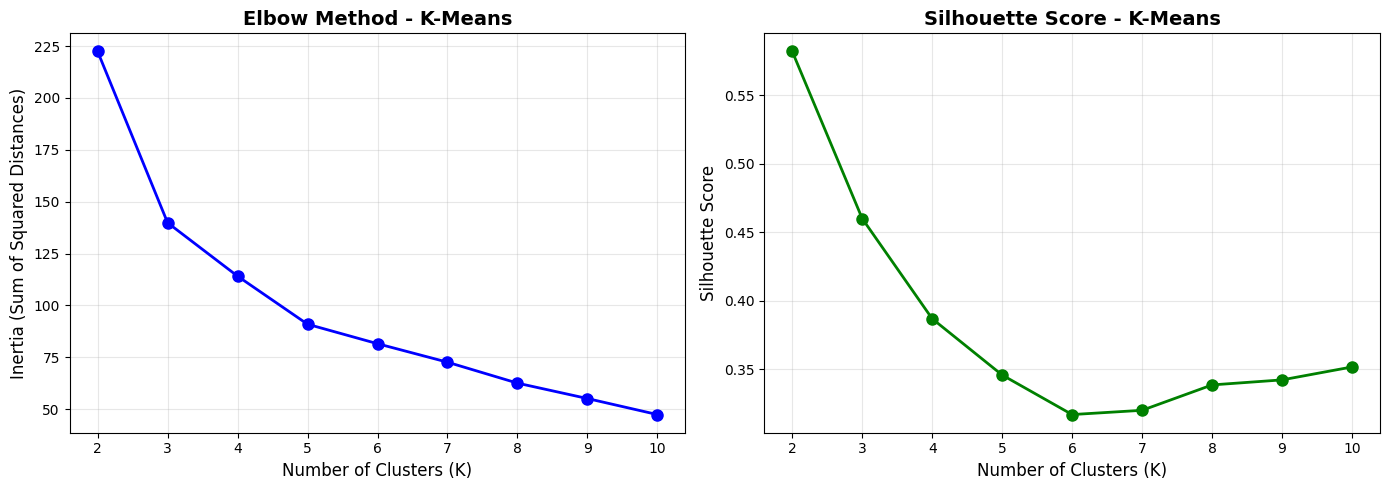


** Based on Elbow Method, K=3 looks optimal **


In [ ]:
# Find optimal number of clusters using Elbow Method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)  # Sum of squared distances
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette Score={score:.3f}")

# Plot Elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Sum of Squared Distances)', fontsize=12)
ax1.set_title('Elbow Method - K-Means', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score - K-Means', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n** Based on Elbow Method, K=3 looks optimal **")

In [ ]:
# Train K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means Results:")
print(f"Number of clusters: {len(np.unique(kmeans_labels))}")
print(f"Cluster sizes: {np.bincount(kmeans_labels)}")
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.3f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_score(X_scaled, kmeans_labels):.2f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, kmeans_labels):.3f}")

print(f"\nCluster Centers (in original space):")
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
for i, center in enumerate(centers_original):
    print(f"Cluster {i}: {center}")

K-Means Results:
Number of clusters: 3
Cluster sizes: [53 50 47]
Silhouette Score: 0.460
Calinski-Harabasz Index: 241.90
Davies-Bouldin Index: 0.834

Cluster Centers (in original space):
Cluster 0: [5.80188679 2.67358491 4.36981132 1.41320755]
Cluster 1: [5.006 3.428 1.462 0.246]
Cluster 2: [6.78085106 3.09574468 5.5106383  1.97234043]


## Step 6: Visualize K-Means Results in 2D

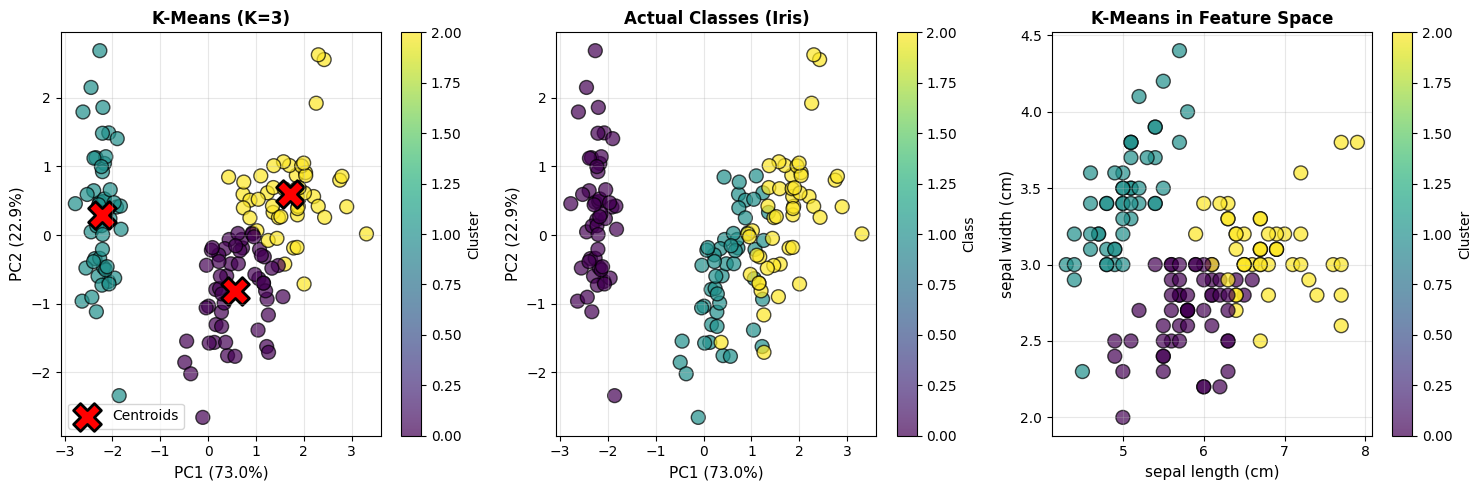

In [ ]:
# Plot K-Means results in 2D (PCA space)
plt.figure(figsize=(15, 5))

# Plot 1: K-Means clusters
plt.subplot(1, 3, 1)
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels,
                       cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=1)
kmeans_centers_pca = pca_2d.transform(kmeans.cluster_centers_)
plt.scatter(kmeans_centers_pca[:, 0], kmeans_centers_pca[:, 1], c='red',
            marker='X', s=400, edgecolors='black', linewidth=2, label='Centroids')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
plt.title('K-Means (K=3)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Actual classes (for comparison)
plt.subplot(1, 3, 2)
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_true,
                       cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=1)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
plt.title('Actual Classes (Iris)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Class')
plt.grid(True, alpha=0.3)

# Plot 3: Feature space scatter
plt.subplot(1, 3, 3)
scatter = plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels,
                       cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=1)
plt.xlabel(feature_names[0], fontsize=11)
plt.ylabel(feature_names[1], fontsize=11)
plt.title(f'K-Means in Feature Space', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7: 3D Visualization of K-Means Results

In [ ]:
# Interactive 3D plot using Plotly
fig = go.Figure()

# Add data points
for cluster in np.unique(kmeans_labels):
    mask = kmeans_labels == cluster
    fig.add_trace(go.Scatter3d(
        x=X_pca_3d[mask, 0],
        y=X_pca_3d[mask, 1],
        z=X_pca_3d[mask, 2],
        mode='markers',
        name=f'Cluster {cluster}',
        marker=dict(size=8, opacity=0.7)
    ))

# Add centroids
kmeans_centers_pca_3d = pca_3d.transform(kmeans.cluster_centers_)
fig.add_trace(go.Scatter3d(
    x=kmeans_centers_pca_3d[:, 0],
    y=kmeans_centers_pca_3d[:, 1],
    z=kmeans_centers_pca_3d[:, 2],
    mode='markers',
    name='Centroids',
    marker=dict(size=15, color='red', symbol='x', line=dict(color='black', width=2))
))

fig.update_layout(
    title='K-Means Clustering - 3D View',
    scene=dict(
        xaxis_title=f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})',
        yaxis_title=f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})',
        zaxis_title=f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})'
    ),
    height=700
)

fig.show()

## Step 8: Algorithm 2 - DBSCAN (Density-Based Clustering)

**What is DBSCAN?**
- Groups points that are close together with high density
- Can find clusters of arbitrary shape (not just spherical)
- Identifies outliers (noise points)
- **Hyperparameters**:
  - `eps`: Maximum distance between points in a cluster
  - `min_samples`: Minimum points in a neighborhood to form a cluster

**Advantage**: No need to specify number of clusters
**Disadvantage**: Sensitive to epsilon parameter

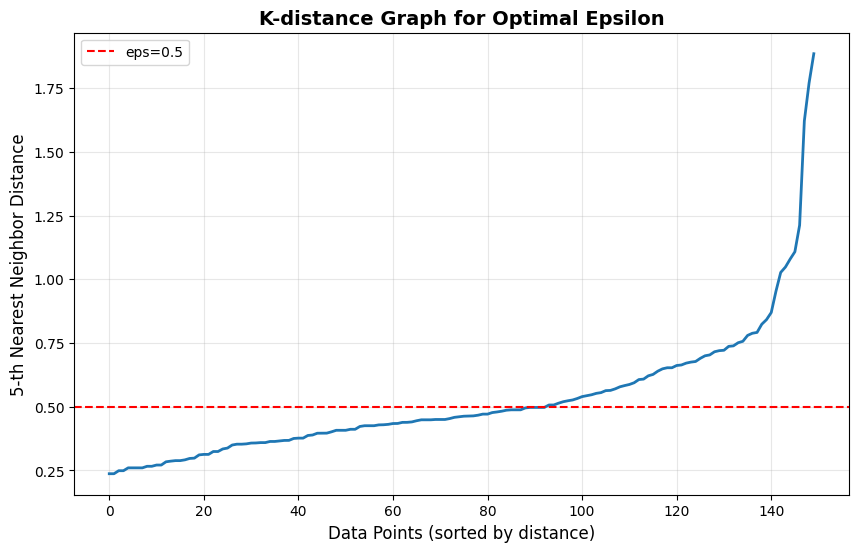

Recommended epsilon: around 0.4-0.6


In [ ]:
# Find optimal epsilon using k-distance graph
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances, linewidth=2)
plt.xlabel('Data Points (sorted by distance)', fontsize=12)
plt.ylabel('5-th Nearest Neighbor Distance', fontsize=12)
plt.title('K-distance Graph for Optimal Epsilon', fontsize=14, fontweight='bold')
plt.axhline(y=0.5, color='r', linestyle='--', label='eps=0.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Recommended epsilon: around 0.4-0.6")

In [ ]:
# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("DBSCAN Results:")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Cluster distribution: {np.bincount(dbscan_labels[dbscan_labels != -1])}")
if n_clusters > 1:
    print(f"Silhouette Score: {silhouette_score(X_scaled, dbscan_labels):.3f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, dbscan_labels):.3f}")

DBSCAN Results:
Number of clusters: 2
Number of noise points: 34
Cluster distribution: [45 71]
Silhouette Score: 0.357
Davies-Bouldin Index: 7.124


## Step 9: Visualize DBSCAN Results in 2D & 3D

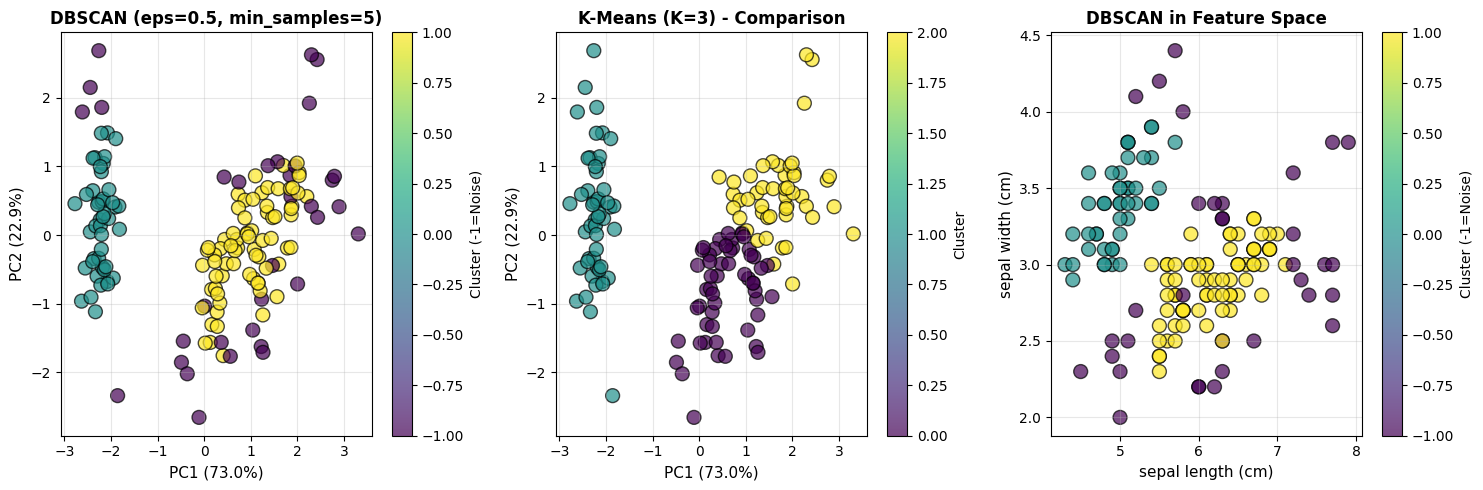

In [ ]:
# 2D visualization
plt.figure(figsize=(15, 5))

# DBSCAN clusters
plt.subplot(1, 3, 1)
colors = ['red' if label == -1 else label for label in dbscan_labels]
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=dbscan_labels,
                       cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=1)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
plt.title('DBSCAN (eps=0.5, min_samples=5)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Cluster (-1=Noise)')
plt.grid(True, alpha=0.3)

# K-Means for comparison
plt.subplot(1, 3, 2)
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels,
                       cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=1)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
plt.title('K-Means (K=3) - Comparison', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

# Feature space
plt.subplot(1, 3, 3)
scatter = plt.scatter(X[:, 0], X[:, 1], c=dbscan_labels,
                       cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=1)
plt.xlabel(feature_names[0], fontsize=11)
plt.ylabel(feature_names[1], fontsize=11)
plt.title('DBSCAN in Feature Space', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Cluster (-1=Noise)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 3D visualization of DBSCAN
fig = go.Figure()

# Add data points
for cluster in np.unique(dbscan_labels):
    mask = dbscan_labels == cluster
    cluster_name = f'Noise' if cluster == -1 else f'Cluster {cluster}'
    fig.add_trace(go.Scatter3d(
        x=X_pca_3d[mask, 0],
        y=X_pca_3d[mask, 1],
        z=X_pca_3d[mask, 2],
        mode='markers',
        name=cluster_name,
        marker=dict(size=8, opacity=0.7)
    ))

fig.update_layout(
    title='DBSCAN Clustering - 3D View',
    scene=dict(
        xaxis_title=f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})',
        yaxis_title=f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})',
        zaxis_title=f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})'
    ),
    height=700
)

fig.show()

## Step 10: Algorithm 3 - Hierarchical Clustering

**What is Hierarchical Clustering?**
- Builds a tree structure (dendrogram) of clusters
- **Agglomerative**: Bottom-up approach (start with points, merge clusters)
- **Divisive**: Top-down approach (start with all, split clusters)
- **Linkage methods**:
  - `ward`: Minimizes variance (distance between cluster centers)
  - `complete`: Maximum distance between clusters
  - `average`: Average distance between clusters
  - `single`: Minimum distance between clusters

**Advantage**: Dendrogram shows hierarchical relationships
**Disadvantage**: Computational complexity O(n²)

In [ ]:
# Agglomerative Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

print("Hierarchical Clustering Results:")
print(f"Number of clusters: {len(np.unique(hierarchical_labels))}")
print(f"Cluster sizes: {np.bincount(hierarchical_labels)}")
print(f"Silhouette Score: {silhouette_score(X_scaled, hierarchical_labels):.3f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_score(X_scaled, hierarchical_labels):.2f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, hierarchical_labels):.3f}")

Hierarchical Clustering Results:
Number of clusters: 3
Cluster sizes: [71 49 30]
Silhouette Score: 0.447
Calinski-Harabasz Index: 222.72
Davies-Bouldin Index: 0.803


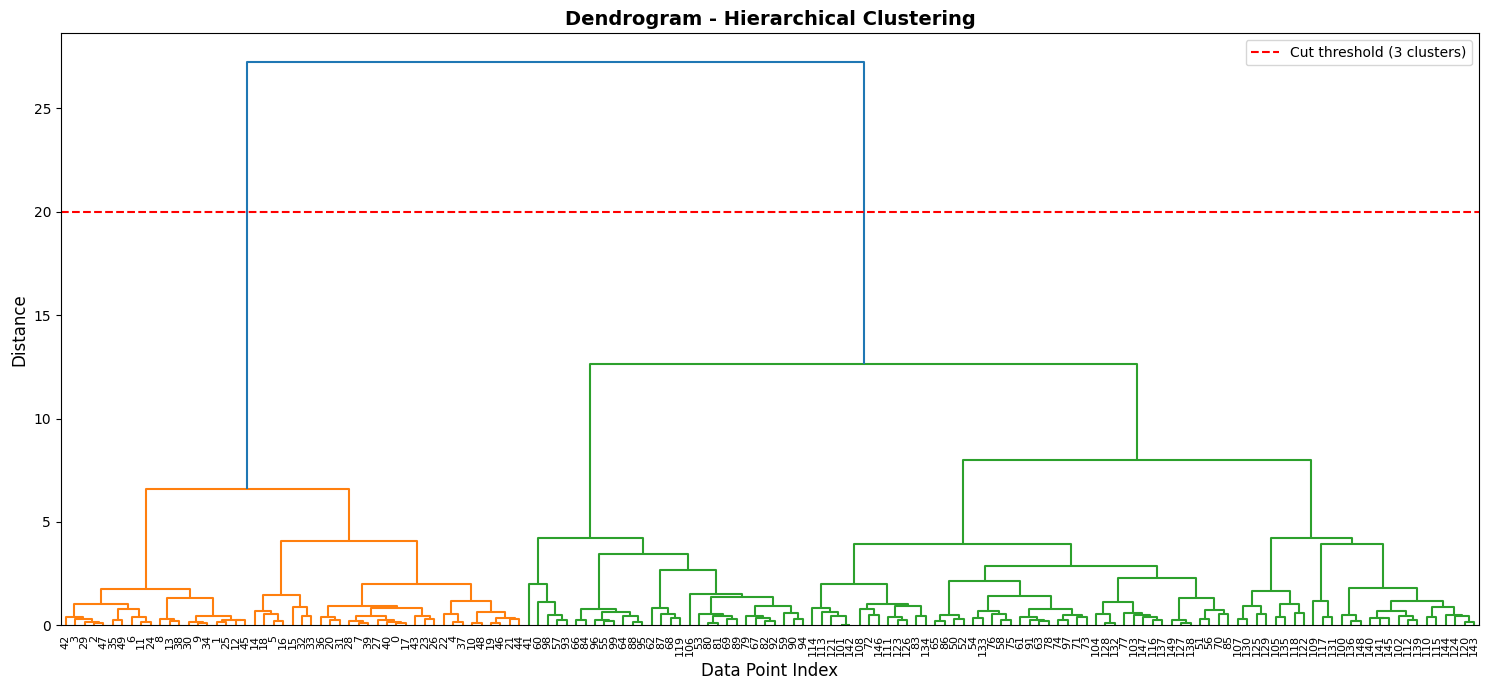

In [ ]:
# Create dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# Compute linkage matrix
linkage_matrix = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(15, 7))
dendrogram(linkage_matrix,
           labels=range(len(X_scaled)),
           leaf_font_size=8,
           color_threshold=20)
plt.axhline(y=20, color='red', linestyle='--', label='Cut threshold (3 clusters)')
plt.xlabel('Data Point Index', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.title('Dendrogram - Hierarchical Clustering', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## Step 11: Visualize Hierarchical Clustering Results

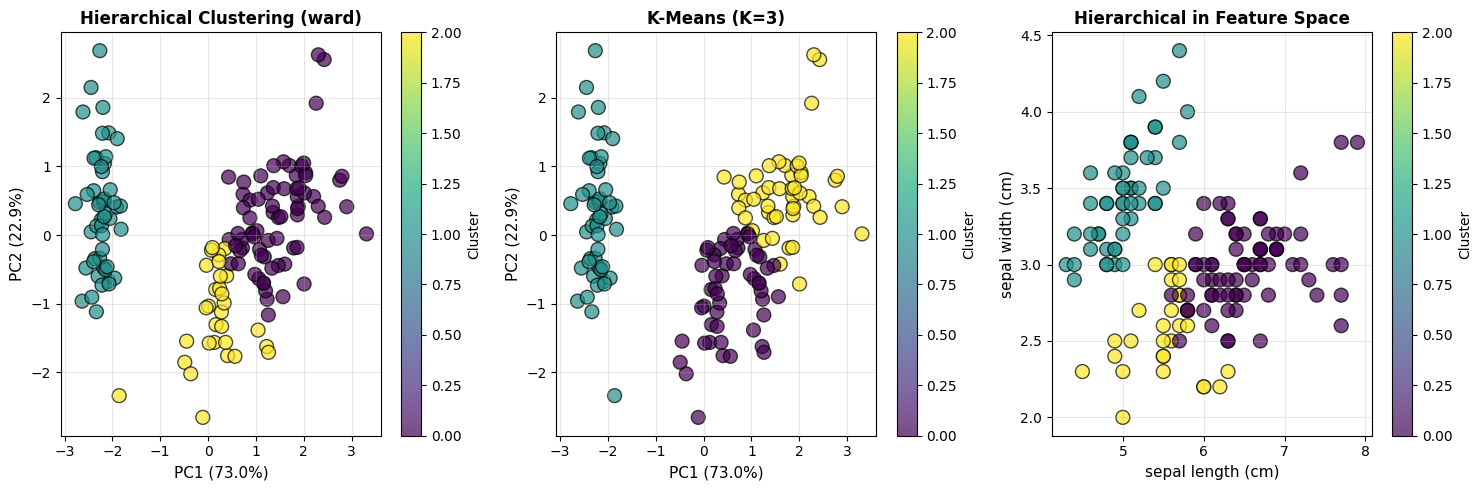

In [ ]:
# 2D visualization
plt.figure(figsize=(15, 5))

# Hierarchical
plt.subplot(1, 3, 1)
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=hierarchical_labels,
                       cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=1)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
plt.title('Hierarchical Clustering (ward)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

# K-Means comparison
plt.subplot(1, 3, 2)
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels,
                       cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=1)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
plt.title('K-Means (K=3)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

# Feature space
plt.subplot(1, 3, 3)
scatter = plt.scatter(X[:, 0], X[:, 1], c=hierarchical_labels,
                       cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=1)
plt.xlabel(feature_names[0], fontsize=11)
plt.ylabel(feature_names[1], fontsize=11)
plt.title('Hierarchical in Feature Space', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 3D visualization of Hierarchical Clustering
fig = go.Figure()

for cluster in np.unique(hierarchical_labels):
    mask = hierarchical_labels == cluster
    fig.add_trace(go.Scatter3d(
        x=X_pca_3d[mask, 0],
        y=X_pca_3d[mask, 1],
        z=X_pca_3d[mask, 2],
        mode='markers',
        name=f'Cluster {cluster}',
        marker=dict(size=8, opacity=0.7)
    ))

fig.update_layout(
    title='Hierarchical Clustering - 3D View',
    scene=dict(
        xaxis_title=f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})',
        yaxis_title=f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})',
        zaxis_title=f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})'
    ),
    height=700
)

fig.show()

## Step 14: Comprehensive Algorithm Comparison

In [ ]:
# Create comparison table
comparison_data = {
    'Algorithm': ['K-Means', 'DBSCAN', 'Hierarchical'],
    'Silhouette Score': [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, dbscan_labels) if n_clusters > 1 else np.nan,
        silhouette_score(X_scaled, hierarchical_labels)
    ],
    'Calinski-Harabasz': [
        calinski_harabasz_score(X_scaled, kmeans_labels),
        calinski_harabasz_score(X_scaled, dbscan_labels) if n_clusters > 1 else np.nan,
        calinski_harabasz_score(X_scaled, hierarchical_labels)
    ],
    'Davies-Bouldin': [
        davies_bouldin_score(X_scaled, kmeans_labels),
        davies_bouldin_score(X_scaled, dbscan_labels) if n_clusters > 1 else np.nan,
        davies_bouldin_score(X_scaled, hierarchical_labels)
    ],
    'N Clusters': [
        len(np.unique(kmeans_labels)),
        len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0),
        len(np.unique(hierarchical_labels))
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("CLUSTERING ALGORITHMS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("\nMetric Interpretations:")
print("• Silhouette Score: [-1, 1], Higher is better (ideal > 0.5)")
print("• Calinski-Harabasz: [0, ∞], Higher is better")
print("• Davies-Bouldin: [0, ∞], Lower is better")